In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# values = [90, 96, 86, 108, 99, 87, 100]
# labs = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul']

# plt.ylabel('y title')
# plt.xlabel('x title')
# plt.bar(labs, values)
# plt.show()

In [3]:
ImageNumber = 187

In [4]:
# image = cv2.imread("C:/Users/DELL1/Pictures/basicPlot.png")
# image = cv2.imread("C:/Users/DELL1/Pictures/basicPlotBars.png")
# image = cv2.imread("C:/College/Sem 08/Major Project/Graphs/Bar/Master.jpg")
# image = cv2.imread("C:/College/Sem 08/Major Project/Graphs/Bar/graph4.png")
# image = cv2.imread(f'c:\\College\\Sem 08\\Major Project\\Graphs\\Bar\\Testing\\testImages\\{ImageNumber}\\{ImageNumber}.png')
image = cv2.imread(f'c:\\College\\Sem 08\\Major Project\\Graphs\\Bar\\Testing_New\\testImages\\{ImageNumber}\\{ImageNumber}.png')
# image = cv2.imread("C:/Users/DELL1/Downloads/graph-2.png")

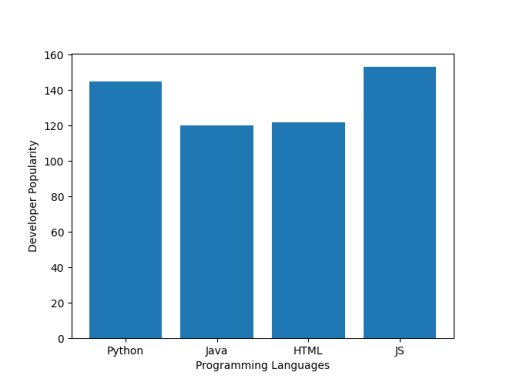

In [5]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [6]:
ab = 7
bc = 7

In [7]:
height, width, channels = image.shape
height_part = height//ab
width_part = width//bc

In [8]:
first_verti = image[:, :width_part]
last_hori = image[-height_part:, :]

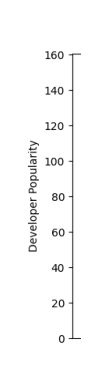

In [9]:
# cv2.imshow('First Vertical Strip', first_verti)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
plt.imshow(cv2.cvtColor(first_verti, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

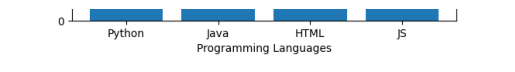

In [10]:
# cv2.imshow('Last Horiontal Strip', last_hori)
plt.imshow(cv2.cvtColor(last_hori, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [11]:
grey_first_verti = cv2.cvtColor(first_verti, cv2.COLOR_BGR2GRAY)
grey_last_hori = cv2.cvtColor(last_hori, cv2.COLOR_BGR2GRAY)

cv2.imshow('Grey Scale Strip Verti', grey_first_verti)
cv2.imshow('Grey Scale Strip Horiz', grey_last_hori)

cv2.waitKey(0)
cv2.destroyAllWindows()

X-Axis

In [12]:
import keras_ocr

pipeline = keras_ocr.pipeline.Pipeline()

images = [keras_ocr.tools.read(last_hori)]

predictions = pipeline.recognize(images)

imageWithBoxKeras = last_hori.copy()

for prediction in predictions[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKeras, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKeras)
cv2.waitKey(0)
cv2.destroyAllWindows() 

Looking for C:\Users\DELL1\.keras-ocr\craft_mlt_25k.h5
Instructions for updating:
Use `tf.image.resize(...method=ResizeMethod.BILINEAR...)` instead.
Looking for C:\Users\DELL1\.keras-ocr\crnn_kurapan.h5
1/1 [==============================] - 4s 4s/step


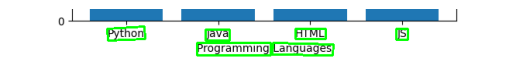

In [13]:
# cv2.imshow('Image with Bounding Boxes', imageWithBoxKeras)
plt.imshow(cv2.cvtColor(imageWithBoxKeras, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [14]:
import pandas as pd

def predictions_to_dataframe(predictions):
    data_for_df = []
    
    for prediction in predictions[0]:  
        text, box = prediction
        x_center = (box[:, 0].min() + box[:, 0].max()) / 2
        y_center = (box[:, 1].min() + box[:, 1].max()) / 2
        box_width = box[:, 0].max() - box[:, 0].min()
        box_height = box[:, 1].max() - box[:, 1].min()
        box = box
        data_for_df.append({
            'text': text,
            'x_center': x_center, 
            'y_center': y_center, 
            'box_height': box_height, 
            'box_width': box_width,
            'box': box
        })
    
    return pd.DataFrame(data_for_df)

In [16]:
df = predictions_to_dataframe(predictions)
df

,text,x_center,y_center,box_height,box_width,box
0,python,149.988693,31.762445,17.882351,49.013573,"[[125.48191, 25.119911], [173.75339, 22.82127]..."
1,html,387.500000,31.500000,13.000000,39.000000,"[[368.0, 25.0], [407.0, 25.0], [407.0, 38.0], ..."
2,js,505.500000,32.000000,14.000000,15.000000,"[[498.0, 25.0], [513.0, 25.0], [513.0, 39.0], ..."
3,java,267.500000,33.000000,14.000000,31.000000,"[[252.0, 26.0], [283.0, 26.0], [283.0, 40.0], ..."
4,programming,288.500000,51.000000,16.000000,95.000000,"[[241.0, 43.0], [336.0, 43.0], [336.0, 59.0], ..."
5,languages,377.965820,51.823029,15.880867,78.332153,"[[339.01642, 43.882595], [417.1319, 45.031353]..."


X-Axis Label

In [17]:
yMax = df['y_center'].mode()[0]
yMax

31.5

In [124]:
x_label = df[(df['y_center'] >= (yMax - 5)) & (df['y_center'] <= (yMax + 5))].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_label

,text,x_center,y_center,box_height,box_width,box
0,python,149.988693,31.762445,17.882351,49.013573,"[[125.48191, 25.119911], [173.75339, 22.82127]..."
1,java,267.500000,33.000000,14.000000,31.000000,"[[252.0, 26.0], [283.0, 26.0], [283.0, 40.0], ..."
2,html,387.500000,31.500000,13.000000,39.000000,"[[368.0, 25.0], [407.0, 25.0], [407.0, 38.0], ..."
3,js,505.500000,32.000000,14.000000,15.000000,"[[498.0, 25.0], [513.0, 25.0], [513.0, 39.0], ..."


In [125]:
k = len(x_label)-1
l = k
dis = 0

for indx in x_label.index:
    if k > 0:
        dis += abs(x_label['x_center'][indx] - x_label['x_center'][indx+1])
        k -= 1
    else:
        break

In [126]:
avg_dis = dis/l
avg_dis

118.50376892089844

In [127]:
# x_labels = []
# xlabel = x_label['text'][0]

# for indx in x_label.index:
#     if l > 0:
#         kml = abs(x_label['x_center'][indx] - x_label['x_center'][indx+1])
#         if kml <= avg_dis-5:
#             xlabel += x_label['text'][indx+1]
#             l -= 1
#         else:
#            x_labels.append(xlabel) 
#            xlabel = x_label['text'][indx+1]
#            l -= 1
           
# x_labels.append(xlabel)
# x_labels

In [128]:
x_labelsWithCent = []
xlabel = x_label['text'][0]
labCent = x_label['x_center'][0]
kmkmkmk = 1

for indx in x_label.index:
    if l > 0:
        kml = abs(x_label['x_center'][indx] - x_label['x_center'][indx+1])
        if kml <= (avg_dis-5):
            xlabel += ' ' + x_label['text'][indx+1] 
            labCent += x_label['x_center'][indx+1]
            kmkmkmk += 1
            l -= 1
        else:
           labCent = labCent/kmkmkmk
           x_labelsWithCent.append((xlabel.strip(), labCent)) 
           xlabel = x_label['text'][indx+1]
           labCent = x_label['x_center'][indx+1]
           kmkmkmk = 1
           l -= 1

labCent = labCent/kmkmkmk           
x_labelsWithCent.append((xlabel, labCent))
x_labelsWithCent

[('python', 149.9886932373047),
 ('java', 267.5),
 ('html', 387.5),
 ('js', 505.5)]

X-Axis Title

In [129]:
x_title = df[df['y_center'] > (yMax + 5)].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_title

,text,x_center,y_center,box_height,box_width,box
0,programming,288.50000,51.000000,16.000000,95.000000,"[[241.0, 43.0], [336.0, 43.0], [336.0, 59.0], ..."
1,languages,377.96582,51.823029,15.880867,78.332153,"[[339.01642, 43.882595], [417.1319, 45.031353]..."


In [130]:
if x_title.empty:
    yMax1 = 0
else: 
    yMax1 = x_title['y_center'].mode()[0] 

yMax1

51.0

In [131]:
x_title = x_title[(x_title['y_center'] >= (yMax1 - 5)) & (x_title['y_center'] <= (yMax1 + 5))].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_title

,text,x_center,y_center,box_height,box_width,box
0,programming,288.50000,51.000000,16.000000,95.000000,"[[241.0, 43.0], [336.0, 43.0], [336.0, 59.0], ..."
1,languages,377.96582,51.823029,15.880867,78.332153,"[[339.01642, 43.882595], [417.1319, 45.031353]..."


In [132]:
if x_title.empty:
    xtitle = ''
else:
    xtitle = ''

    for indx in x_title.index:
        xtitle += x_title['text'][indx] + ' '
            
    xtitle = xtitle.strip()
xtitle

'programming languages'

X-Axis Detection

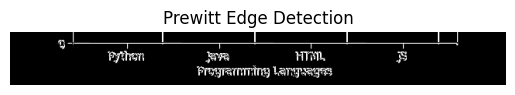

In [133]:
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=int)
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=int)

img_prewittx = cv2.filter2D(grey_last_hori, -1, kernelx)
img_prewitty = cv2.filter2D(grey_last_hori, -1, kernely)

img_prewitt = img_prewittx + img_prewitty

plt.imshow(img_prewitt, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

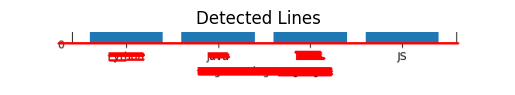

In [134]:
linesInLastHori = last_hori.copy()

_, binary_prewitt = cv2.threshold(img_prewitt, 50, 255, cv2.THRESH_BINARY)
linesP = cv2.HoughLinesP(binary_prewitt, 1, np.pi/180, 50, minLineLength=20, maxLineGap=10)

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        cv2.line(linesInLastHori, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
linesInLastHori = cv2.cvtColor(linesInLastHori, cv2.COLOR_BGR2RGB)
plt.imshow(linesInLastHori )
plt.title('Detected Lines')
plt.axis('off')
plt.show()

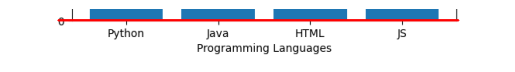

In [135]:
xAxisDetected = last_hori.copy()

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        if y1 < yMax and y2 < yMax:
            cv2.line(xAxisDetected, (x1, y1), (x2, y2), (0, 0, 255), 2)
            break
        
xAxisDetected = cv2.cvtColor(xAxisDetected, cv2.COLOR_BGR2RGB)
plt.imshow(xAxisDetected )
# plt.title('Detected X-Axis')
plt.axis('off')
plt.show()

In [136]:
xAxisCordsInStrip = [[x1, y1], [x2, y2]]
xAxisCordsInStrip = sorted(xAxisCordsInStrip, key=lambda x: x[0])
xAxisCordsInStrip

[[62, 14], [578, 14]]

In [137]:
original_height_part = height - height_part

xAxisCords = [[xAxisCordsInStrip[0][0], xAxisCordsInStrip[0][1] + original_height_part], [xAxisCordsInStrip[1][0], xAxisCordsInStrip[1][1] + original_height_part]]
xAxisCords

[[62, 426], [578, 426]]

In [138]:
xAxisCord = 0

for i in xAxisCords:
    xAxisCord+=i[1]
    
xAxisCord = xAxisCord/2
xAxisCord

426.0

In [139]:
x_label_copy = x_label.copy()

for index, row in x_label_copy.iterrows():
    arr = row['box']
    arr[:, 1] += original_height_part
    x_label_copy.at[index, 'box'] = arr

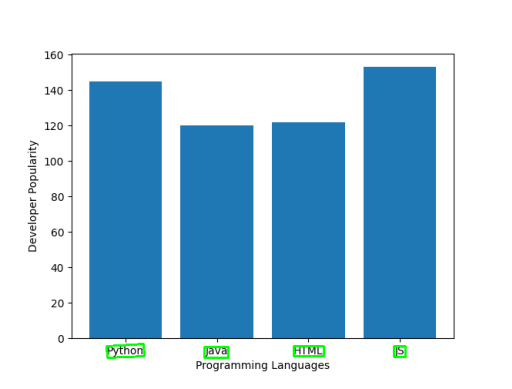

In [140]:
image11 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image1223 = image11.copy()

for indx in x_label_copy.index:
    box = x_label_copy['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

In [141]:
x_title_copy = x_title.copy()

for index, row in x_title_copy.iterrows():
    arr = row['box']
    arr[:, 1] += original_height_part
    x_title_copy.at[index, 'box'] = arr

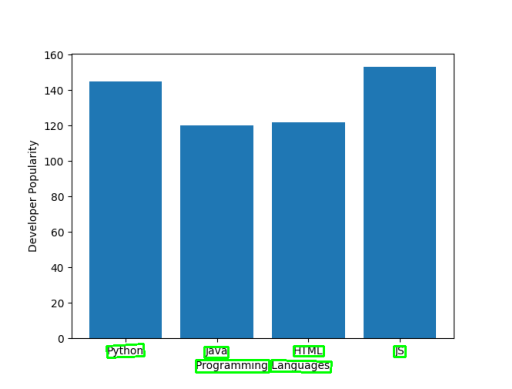

In [142]:
for indx in x_title_copy.index:
    box = x_title_copy['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

Y-Axis

In [143]:
images = [keras_ocr.tools.read(first_verti)]

predictions1 = pipeline.recognize(images)

imageWithBoxKerasVerti = first_verti.copy()

for prediction in predictions1[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKerasVerti, [box], isClosed=True, color=(0, 255, 0), thickness=2)

# cv2.imshow('Image with Bounding Boxes', imageWithBoxKerasVerti)
# cv2.waitKey(0)
# cv2.destroyAllWindows() 

1/1 [==============================] - 1s 1s/step


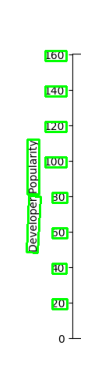

In [144]:
plt.imshow(cv2.cvtColor(imageWithBoxKerasVerti, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Y-Axis Labels

In [145]:
df1 = predictions_to_dataframe(predictions1)
df1

,text,x_center,y_center,box_height,box_width,box
0,100,58.500000,60.500000,13.000000,27.000000,"[[45.0, 54.0], [72.0, 54.0], [72.0, 67.0], [45..."
1,140,58.500000,106.500000,13.000000,27.000000,"[[45.0, 100.0], [72.0, 100.0], [72.0, 113.0], ..."
2,120,58.500000,152.500000,13.000000,27.000000,"[[45.0, 146.0], [72.0, 146.0], [72.0, 159.0], ..."
3,,30.499996,205.499969,71.000000,15.000000,"[[22.999996, 169.99997], [37.999996, 169.99997..."
4,100,58.500000,198.500000,13.000000,27.000000,"[[45.0, 192.0], [72.0, 192.0], [72.0, 205.0], ..."
5,80,63.500000,244.500000,13.000000,19.000000,"[[54.0, 238.0], [73.0, 238.0], [73.0, 251.0], ..."
6,s,30.158382,279.528015,73.874817,17.792587,"[[24.379124, 242.5906], [39.054676, 243.21512]..."
7,60,63.500000,290.500000,13.000000,19.000000,"[[54.0, 284.0], [73.0, 284.0], [73.0, 297.0], ..."
8,40,63.000000,336.500000,13.000000,18.000000,"[[54.0, 330.0], [72.0, 330.0], [72.0, 343.0], ..."
9,20,63.500000,382.500000,13.000000,19.000000,"[[54.0, 376.0], [73.0, 376.0], [73.0, 389.0], ..."


In [146]:
df11 = df1.copy()
df11 = df11[df11['text'].str.isdigit()]
df11['text'] = df11['text'].astype(float)
df11

,text,x_center,y_center,box_height,box_width,box
0,100.0,58.5,60.5,13.0,27.0,"[[45.0, 54.0], [72.0, 54.0], [72.0, 67.0], [45..."
1,140.0,58.5,106.5,13.0,27.0,"[[45.0, 100.0], [72.0, 100.0], [72.0, 113.0], ..."
2,120.0,58.5,152.5,13.0,27.0,"[[45.0, 146.0], [72.0, 146.0], [72.0, 159.0], ..."
4,100.0,58.5,198.5,13.0,27.0,"[[45.0, 192.0], [72.0, 192.0], [72.0, 205.0], ..."
5,80.0,63.5,244.5,13.0,19.0,"[[54.0, 238.0], [73.0, 238.0], [73.0, 251.0], ..."
7,60.0,63.5,290.5,13.0,19.0,"[[54.0, 284.0], [73.0, 284.0], [73.0, 297.0], ..."
8,40.0,63.0,336.5,13.0,18.0,"[[54.0, 330.0], [72.0, 330.0], [72.0, 343.0], ..."
9,20.0,63.5,382.5,13.0,19.0,"[[54.0, 376.0], [73.0, 376.0], [73.0, 389.0], ..."


In [147]:
xMax = df11['x_center'].mode()[0]
xMax

58.5

In [148]:
y_label = df11[(df11['x_center'] >= (xMax - 5)) & (df11['x_center'] <= (xMax + 5))].sort_values(by='text', ascending=False).reset_index(drop=True)
y_label

,text,x_center,y_center,box_height,box_width,box
0,140.0,58.5,106.5,13.0,27.0,"[[45.0, 100.0], [72.0, 100.0], [72.0, 113.0], ..."
1,120.0,58.5,152.5,13.0,27.0,"[[45.0, 146.0], [72.0, 146.0], [72.0, 159.0], ..."
2,100.0,58.5,60.5,13.0,27.0,"[[45.0, 54.0], [72.0, 54.0], [72.0, 67.0], [45..."
3,100.0,58.5,198.5,13.0,27.0,"[[45.0, 192.0], [72.0, 192.0], [72.0, 205.0], ..."
4,80.0,63.5,244.5,13.0,19.0,"[[54.0, 238.0], [73.0, 238.0], [73.0, 251.0], ..."
5,60.0,63.5,290.5,13.0,19.0,"[[54.0, 284.0], [73.0, 284.0], [73.0, 297.0], ..."
6,40.0,63.0,336.5,13.0,18.0,"[[54.0, 330.0], [72.0, 330.0], [72.0, 343.0], ..."
7,20.0,63.5,382.5,13.0,19.0,"[[54.0, 376.0], [73.0, 376.0], [73.0, 389.0], ..."


In [149]:
y_label['diff'] = (y_label['text'].diff(periods=-1).abs())
y_label['pdiff'] = (y_label['y_center'].diff(periods=-1).abs())
y_label['vpp'] = (y_label['text'].diff(periods=-1).abs())/y_label['y_center'].diff(periods=-1).abs()
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
0,140.0,58.5,106.5,13.0,27.0,"[[45.0, 100.0], [72.0, 100.0], [72.0, 113.0], ...",20.0,46.0,0.434783
1,120.0,58.5,152.5,13.0,27.0,"[[45.0, 146.0], [72.0, 146.0], [72.0, 159.0], ...",20.0,92.0,0.217391
2,100.0,58.5,60.5,13.0,27.0,"[[45.0, 54.0], [72.0, 54.0], [72.0, 67.0], [45...",0.0,138.0,0.000000
3,100.0,58.5,198.5,13.0,27.0,"[[45.0, 192.0], [72.0, 192.0], [72.0, 205.0], ...",20.0,46.0,0.434783
4,80.0,63.5,244.5,13.0,19.0,"[[54.0, 238.0], [73.0, 238.0], [73.0, 251.0], ...",20.0,46.0,0.434783
5,60.0,63.5,290.5,13.0,19.0,"[[54.0, 284.0], [73.0, 284.0], [73.0, 297.0], ...",20.0,46.0,0.434783
6,40.0,63.0,336.5,13.0,18.0,"[[54.0, 330.0], [72.0, 330.0], [72.0, 343.0], ...",20.0,46.0,0.434783
7,20.0,63.5,382.5,13.0,19.0,"[[54.0, 376.0], [73.0, 376.0], [73.0, 389.0], ...",NaN,NaN,NaN


In [150]:
most_common_diff = y_label['diff'][:-1].mode()[0]
most_common_diff

20.0

In [151]:
most_common_vpp = y_label['vpp'][:-1].mode()[0]

if most_common_vpp == 0:
    frequency = y_label['vpp'].value_counts()
    print(frequency)
    if len(frequency) > 1:
        most_common_vpp = frequency.index[1] 

most_common_vpp

0.43478260869565216

In [152]:
inRange = y_label['vpp'].between(most_common_vpp - 0.05, most_common_vpp + 0.05)

# y_label = y_label[(y_label['diff'] == most_common_diff) | inRange | (y_label.index == y_label.index[-1])]
y_label = y_label[(inRange | (y_label.index == y_label.index[-1]))]
# y_label = y_label.drop(columns=['diff'])

y_label.reset_index(drop=True, inplace=True)
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
0,140.0,58.5,106.5,13.0,27.0,"[[45.0, 100.0], [72.0, 100.0], [72.0, 113.0], ...",20.0,46.0,0.434783
1,100.0,58.5,198.5,13.0,27.0,"[[45.0, 192.0], [72.0, 192.0], [72.0, 205.0], ...",20.0,46.0,0.434783
2,80.0,63.5,244.5,13.0,19.0,"[[54.0, 238.0], [73.0, 238.0], [73.0, 251.0], ...",20.0,46.0,0.434783
3,60.0,63.5,290.5,13.0,19.0,"[[54.0, 284.0], [73.0, 284.0], [73.0, 297.0], ...",20.0,46.0,0.434783
4,40.0,63.0,336.5,13.0,18.0,"[[54.0, 330.0], [72.0, 330.0], [72.0, 343.0], ...",20.0,46.0,0.434783
5,20.0,63.5,382.5,13.0,19.0,"[[54.0, 376.0], [73.0, 376.0], [73.0, 389.0], ...",NaN,NaN,NaN


In [153]:
y_label = y_label.reset_index(drop=True)
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
0,140.0,58.5,106.5,13.0,27.0,"[[45.0, 100.0], [72.0, 100.0], [72.0, 113.0], ...",20.0,46.0,0.434783
1,100.0,58.5,198.5,13.0,27.0,"[[45.0, 192.0], [72.0, 192.0], [72.0, 205.0], ...",20.0,46.0,0.434783
2,80.0,63.5,244.5,13.0,19.0,"[[54.0, 238.0], [73.0, 238.0], [73.0, 251.0], ...",20.0,46.0,0.434783
3,60.0,63.5,290.5,13.0,19.0,"[[54.0, 284.0], [73.0, 284.0], [73.0, 297.0], ...",20.0,46.0,0.434783
4,40.0,63.0,336.5,13.0,18.0,"[[54.0, 330.0], [72.0, 330.0], [72.0, 343.0], ...",20.0,46.0,0.434783
5,20.0,63.5,382.5,13.0,19.0,"[[54.0, 376.0], [73.0, 376.0], [73.0, 389.0], ...",NaN,NaN,NaN


In [154]:
indexToDrop  = []
iii = 0
jjj = 1

if (y_label['diff'].iloc[0] != most_common_diff) or (most_common_vpp - 0.005 <= y_label['diff'].iloc[0] <= most_common_vpp + 0.005):
    indexToDrop.append(0)
    iii = jjj
    jjj += 1

In [155]:
while jjj != (len(y_label)):
    kkk = y_label['text'][iii] - y_label['text'][jjj]
    
    if kkk > 0:
       iii = jjj
       jjj += 1
    else:
        indexToDrop.append(jjj)
        jjj+=1
    
indexToDrop

[]

In [156]:
for i in range(len(y_label)):
    if i in indexToDrop:
        y_label.drop(index=i, inplace=True)
        
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
0,140.0,58.5,106.5,13.0,27.0,"[[45.0, 100.0], [72.0, 100.0], [72.0, 113.0], ...",20.0,46.0,0.434783
1,100.0,58.5,198.5,13.0,27.0,"[[45.0, 192.0], [72.0, 192.0], [72.0, 205.0], ...",20.0,46.0,0.434783
2,80.0,63.5,244.5,13.0,19.0,"[[54.0, 238.0], [73.0, 238.0], [73.0, 251.0], ...",20.0,46.0,0.434783
3,60.0,63.5,290.5,13.0,19.0,"[[54.0, 284.0], [73.0, 284.0], [73.0, 297.0], ...",20.0,46.0,0.434783
4,40.0,63.0,336.5,13.0,18.0,"[[54.0, 330.0], [72.0, 330.0], [72.0, 343.0], ...",20.0,46.0,0.434783
5,20.0,63.5,382.5,13.0,19.0,"[[54.0, 376.0], [73.0, 376.0], [73.0, 389.0], ...",NaN,NaN,NaN


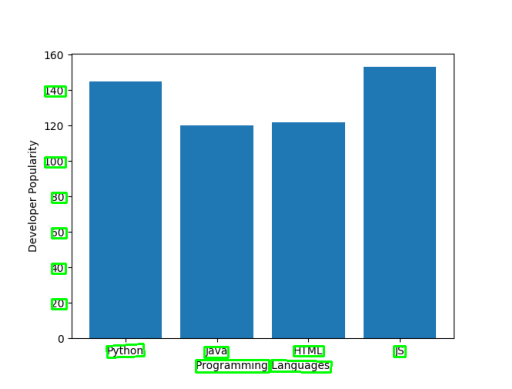

In [157]:
for indx in y_label.index:
    box = y_label['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

Chceck for Equal Pixel Distribution

In [158]:
if len(y_label) == 1:
    most_common_pdiff = y_label['pdiff'][:].mode()[0]
else:
    most_common_pdiff = y_label['pdiff'][:-1].mode()[0]
most_common_pdiff

46.0

In [159]:
y_label[-1:]

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
5,20.0,63.5,382.5,13.0,19.0,"[[54.0, 376.0], [73.0, 376.0], [73.0, 389.0], ...",NaN,NaN,NaN


In [160]:
corVal = y_label['text'].iloc[-1]
corFir = y_label['y_center'].iloc[-1]
betweenFirst = xAxisCord - corFir

print(betweenFirst)

43.5


In [161]:
import math

corVal = y_label['text'].iloc[-1]
corFir = y_label['y_center'].iloc[-1]
betweenFirst = xAxisCord - corFir

if corVal == most_common_diff:
    if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
        # Case-1
        print("Case-1")
        toAdd = 0
        fromCal = xAxisCord
    else:
        # Case-5
        print("Case-5")
        toAdd = corVal
        fromCal = corFir
else:
    if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
        #Case-3
        print("Case-3")
        toAdd = corVal - most_common_diff
        fromCal = xAxisCord
    elif (betweenFirst < most_common_pdiff - 5):
        #Case-7
        print("Case-7")
        toAdd = corVal
        fromCal = corFir
    else:
        dif = betweenFirst/most_common_pdiff
        
        if dif - math.floor(dif) > 0.9:
            dif = math.ceil(dif)
        else:
            dif = math.floor(dif)
            
        # newCorVal = corVal - dif*most_common_diff
        # newCorFir = corFir - dif*most_common_pdiff
        fin = abs(betweenFirst - dif*most_common_pdiff)
        
        if fin < 5:
            newCorVal = corVal - (dif-1)*most_common_diff
            # newCorFir = corFir - (dif-1)*most_common_pdiff
            
            if newCorVal == most_common_diff:
                #Case-2
                print("Case-2")
                toAdd = 0
                fromCal = xAxisCord
            else:
                #Case-4
                print("Case-4")
                toAdd = corVal - (dif)*most_common_diff
                fromCal = xAxisCord
        else:
            newCorVal = corVal - (dif)*most_common_diff
            
            # if newCorVal == most_common_diff:
            
            #Case-6&8
            print("Case-6&8")
            toAdd = newCorVal
            fromCal = xAxisCord-fin
            
            # else:
            #     #Case-8
            #     toAdd = corVal - (dif)*most_common_diff
            #     fromCal = xAxisCord

Case-1


In [162]:
# import math

# corVal = y_label['text'].iloc[-1]
# corFir = y_label['y_center'].iloc[-1]
# betweenFirst = xAxisCord - corFir

# if corVal == most_common_diff:
#     if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
#         # Case-1
#         toAdd = 0
#         fromCal = xAxisCord
#     else:
#         # Case-5
#         toAdd = corVal
#         fromCal = corFir
# else:
#     if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
#         #Case-3
#         toAdd = corVal - most_common_diff
#         fromCal = xAxisCord
#     elif (betweenFirst < most_common_pdiff - 5):
#         #Case-7
#         toAdd = corVal
#         fromCal = corFir
#     else:   
#         dif = betweenFirst/most_common_pdiff

#         if dif - math.floor(dif) > 0.9:
#             dif = math.ceil(dif)
#         else:
#             dif = math.floor(dif)

#         if dif == 1:
#             newCorVal = corVal - most_common_diff
#             newCorFir = corFir - most_common_pdiff
#             newBetweenFirst = xAxisCord - newCorFir
#         else:   
#             newCorVal = corVal - (dif-1)*most_common_diff
#             newCorFir = corFir - (dif-1)*most_common_pdiff
#             newBetweenFirst = xAxisCord - newCorFir


#         if newCorVal == most_common_diff:
#             if (newBetweenFirst > most_common_pdiff - 5) and (newBetweenFirst < most_common_pdiff + 5):
#                 # Case-2
#                 toAdd = 0
#                 fromCal = xAxisCord
#             else:
#                 # Case-6
#                 toAdd = newCorVal
#                 fromCal = newCorFir
#         else:
#             if (newBetweenFirst > most_common_pdiff - 5) and (newBetweenFirst < most_common_pdiff + 5):
#                 # Case-4
#                 toAdd = newCorVal - most_common_diff
#                 fromCal = xAxisCord
#             else:
#                 # Case-8
#                 toAdd = newCorVal
#                 fromCal = newCorFir

In [163]:
# if (corFir > most_common_pdiff + 5):
#     dif = betweenFirst//most_common_pdiff
    
#     fin = abs(betweenFirst - dif*most_common_pdiff)
    
#     if fin < 5:
#         if y_label['text'].iloc[-1] == most_common_diff:
#             toAdd = 0
#             fromCal = xAxisCord
#         else:
#             toAdd = y_label['text'].iloc[-1] - dif*most_common_diff
#             fromCal = xAxisCord
#     else:
#         toAdd = y_label['text'].iloc[-1] - dif*most_common_diff
#         fromCal = xAxisCord - fin

In [164]:
# if (corFir > most_common_pdiff + 5):
#     dif = betweenFirst//most_common_pdiff
    
#     fin = abs(betweenFirst - dif*most_common_pdiff)
    
#     if fin < 5:
#         toAdd = 0
#         fromCal = xAxisCord
#     else:
#         toAdd = y_label['text'].iloc[-1] - dif*most_common_diff
#         fromCal = xAxisCord - fin

In [165]:
fromCal

426.0

Value Per Pixel

In [166]:
vpp = 0
tot = len(y_label)-1

for i in range (tot):
    vpp += abs(y_label['text'][i+1] - y_label['text'][i])/abs(y_label['y_center'][i+1] - y_label['y_center'][i])
    
vpp = vpp/tot
vpp

0.43478260869565216

In [167]:
if len(y_label) == 1:   
    vpp = y_label['vpp'][:].mean()
else:
    vpp = y_label['vpp'][:-1].mean()
vpp

0.43478260869565216

Y-Axis Title

In [168]:
rotated_image = cv2.rotate(first_verti, cv2.ROTATE_90_CLOCKWISE)
# rotated_image1 = cv2.rotate(first_verti, cv2.ROTATE_90_COUNTERCLOCKWISE)

cv2.imshow('90 CLOCKWISE', rotated_image)
# cv2.imshow('90 COUNTERCLOCKWISE', rotated_image1)
cv2.waitKey(0)
cv2.destroyAllWindows() 

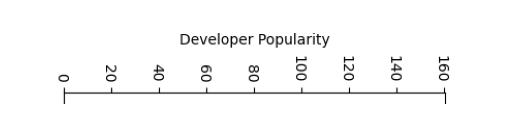

In [215]:
plt.imshow(cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [169]:
images = [keras_ocr.tools.read(rotated_image)]

predictions2 = pipeline.recognize(images)

imageWithBoxKerasRotateColck = rotated_image.copy()

for prediction in predictions2[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKerasRotateColck, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKerasRotateColck)
cv2.waitKey(0)
cv2.destroyAllWindows() 

1/1 [==============================] - 1s 1s/step


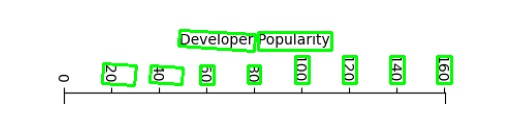

In [170]:
plt.imshow(cv2.cvtColor(imageWithBoxKerasRotateColck, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [171]:
df2 = predictions_to_dataframe(predictions2)
df2

,text,x_center,y_center,box_height,box_width,box
0,popularity,275.500000,30.500000,17.000000,71.000000,"[[240.0, 22.0], [311.0, 22.0], [311.0, 39.0], ..."
1,developer,200.472778,30.435799,20.077820,74.182892,"[[164.3502, 20.396889], [237.56422, 24.972763]..."
2,g,282.500000,58.000000,26.000000,13.000000,"[[276.0, 45.0], [289.0, 45.0], [289.0, 71.0], ..."
3,s,328.500000,58.000000,26.000000,13.000000,"[[322.0, 45.0], [335.0, 45.0], [335.0, 71.0], ..."
4,s,374.500000,58.000000,26.000000,13.000000,"[[368.0, 45.0], [381.0, 45.0], [381.0, 71.0], ..."
5,g,420.000000,58.000000,26.000000,14.000000,"[[413.0, 45.0], [427.0, 45.0], [427.0, 71.0], ..."
6,g,105.682884,63.073940,21.330742,32.712067,"[[90.536964, 52.40857], [122.03892, 54.37744],..."
7,0,190.500000,63.000000,18.000000,13.000000,"[[184.0, 54.0], [197.0, 54.0], [197.0, 72.0], ..."
8,o,236.000000,62.500000,17.000000,12.000000,"[[230.0, 54.0], [242.0, 54.0], [242.0, 71.0], ..."
9,s,151.582870,63.425415,18.082870,32.303894,"[[136.29558, 54.38398], [167.73482, 56.038673]..."


In [172]:
df2 = df2[df2['y_center'] < (xMax-5)].sort_values(by='x_center', ascending=True).reset_index(drop=True)
df2

,text,x_center,y_center,box_height,box_width,box
0,developer,200.472778,30.435799,20.07782,74.182892,"[[164.3502, 20.396889], [237.56422, 24.972763]..."
1,popularity,275.500000,30.500000,17.00000,71.000000,"[[240.0, 22.0], [311.0, 22.0], [311.0, 39.0], ..."


In [173]:
ytitle = ''

for indx in df2.index:
    ytitle += df2['text'][indx] + ' '
        
ytitle = ytitle.strip()
ytitle

'developer popularity'

In [174]:
blahblah = [3, 6]

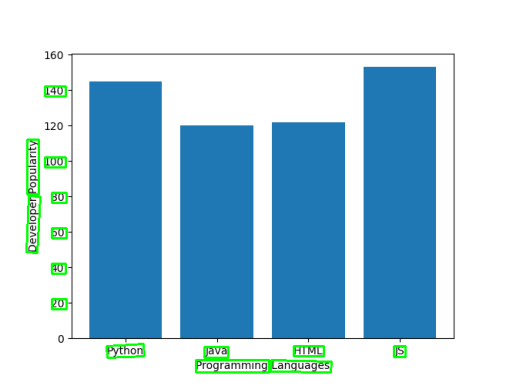

In [175]:
for indx in df1.index:
    if indx in blahblah:
        box = df1['box'][indx]
        box = box.astype(int)
        cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show() 

Y-Axis Detection

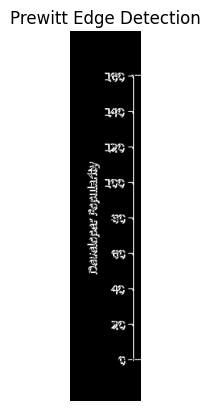

In [176]:
img_prewittx1 = cv2.filter2D(grey_first_verti, -1, kernelx)
img_prewitty1 = cv2.filter2D(grey_first_verti, -1, kernely)

img_prewitt1 = img_prewittx1 + img_prewitty1

plt.imshow(img_prewitt1, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

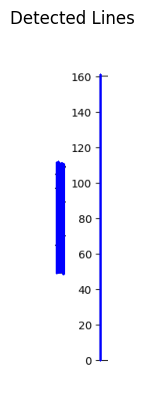

In [177]:
linesInFirstVeti = first_verti.copy()

_, binary_prewitt1 = cv2.threshold(img_prewitt1, 50, 255, cv2.THRESH_BINARY)
linesP1 = cv2.HoughLinesP(binary_prewitt1, 1, np.pi/180, 50, minLineLength=20, maxLineGap=10)

if linesP1 is not None:
    for line in linesP1:
        x1, y1, x2, y2 = line[0]
        cv2.line(linesInFirstVeti, (x1, y1), (x2, y2), (255, 0, 0), 2)
        print()
    
linesInLastHori = cv2.cvtColor(linesInFirstVeti, cv2.COLOR_BGR2RGB)
plt.imshow(linesInLastHori )
plt.title('Detected Lines')
plt.axis('off')
plt.show()

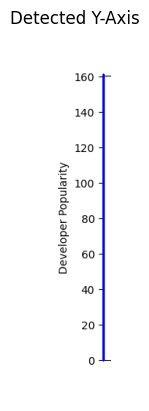

In [178]:
yAxisDetected = first_verti.copy()

if linesP1 is not None:
    for line in linesP1:
        x1, y1, x2, y2 = line[0]
        if x1 > xMax and x2 > xMax:
            cv2.line(yAxisDetected, (x1, y1), (x2, y2), (255, 0, 0), 2)
            break
        
yAxisDetected = cv2.cvtColor(yAxisDetected, cv2.COLOR_BGR2RGB)
plt.imshow(yAxisDetected )
plt.title('Detected Y-Axis')
plt.axis('off')
plt.show()

In [179]:
yAxisCords = [[x1, y1], [x2, y2]]
yAxisCords = sorted(yAxisCords, key=lambda x: x[1])
yAxisCords

[[81, 56], [81, 427]]

In [180]:
yAxisCord = 0

for i in yAxisCords:
    yAxisCord+=i[0]
    
yAxisCord = yAxisCord/2
yAxisCord

81.0

Detcted Both Axes 

In [181]:
detectedAxes = image.copy()

cv2.line(detectedAxes, (xAxisCords[0][0], xAxisCords[0][1]), (xAxisCords[1][0], xAxisCords[1][1]), (0, 0, 255), 2)
cv2.line(detectedAxes, (yAxisCords[0][0], yAxisCords[0][1]), (yAxisCords[1][0], yAxisCords[1][1]), (0, 255, 0), 2)

cv2.imshow('Image with Both Axes', detectedAxes)
cv2.waitKey(0)
cv2.destroyAllWindows()

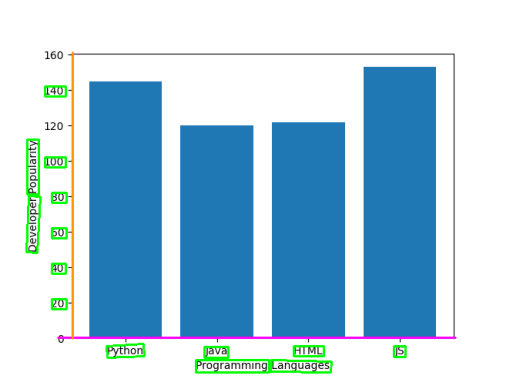

In [182]:
cv2.line(image1223, (xAxisCords[0][0], xAxisCords[0][1]), (xAxisCords[1][0], xAxisCords[1][1]), (255, 0, 255), 2)
cv2.line(image1223, (yAxisCords[0][0], yAxisCords[0][1]), (yAxisCords[1][0], yAxisCords[1][1]), (255, 150, ), 2)

plt.imshow(image1223)
plt.axis('off')
plt.show()

Color Detection

In [183]:
image1 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

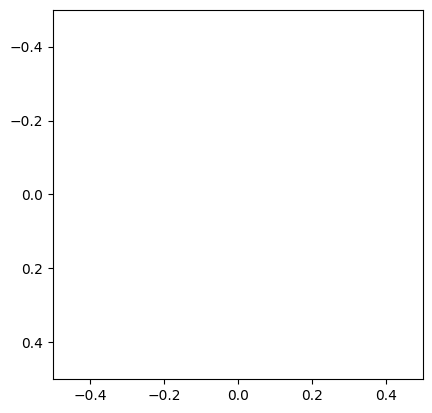

[255.63318 255.63318 255.63318]


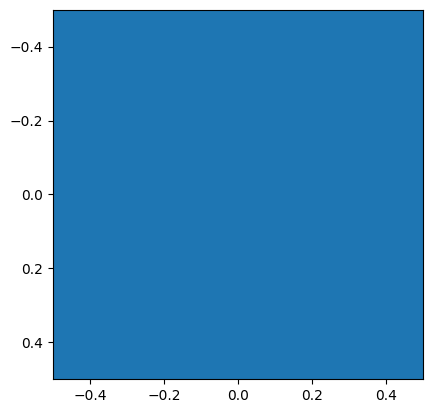

[ 30.99355  118.977425 179.96774 ]


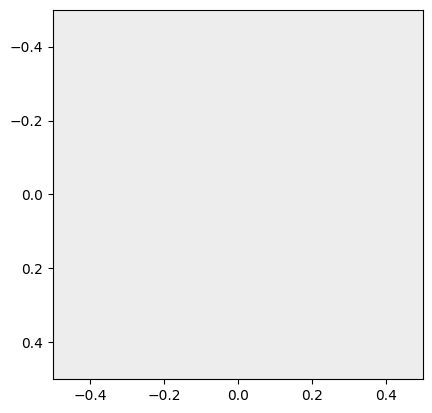

[237.72058 237.72058 237.72058]


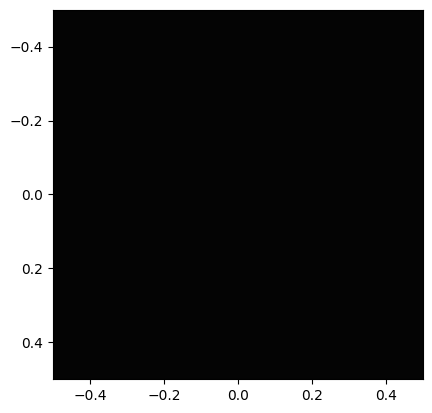

[4.6381226 4.6381226 4.6381226]


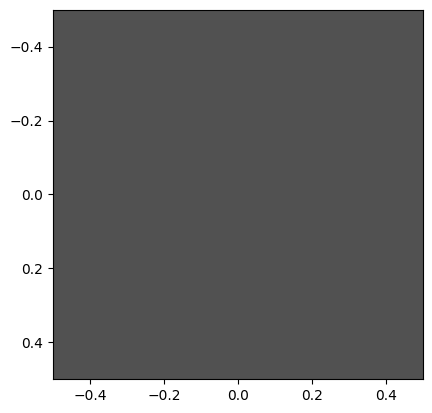

[81.661064 81.661064 81.661064]


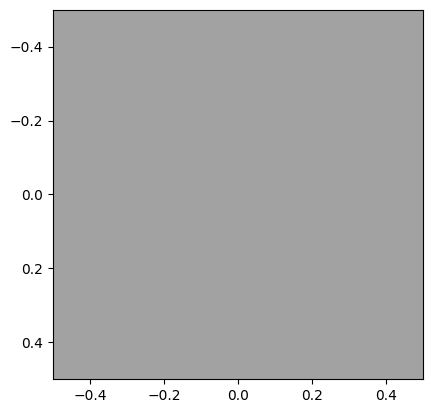

[162.57446 162.57446 162.57446]


In [184]:
pixels = image1.reshape((-1, 3)).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

k = 6

_, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

unique, counts = np.unique(labels, return_counts=True)

sorted_colors = sorted(zip(counts, centers), key=lambda x: x[0], reverse=True)

sorted_colors = [tpl[1] for tpl in sorted_colors]

for color in sorted_colors:
    plt.imshow([[color.astype(np.uint8)/255]])
    plt.show()
    print(color)

Bar Detection

In [185]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

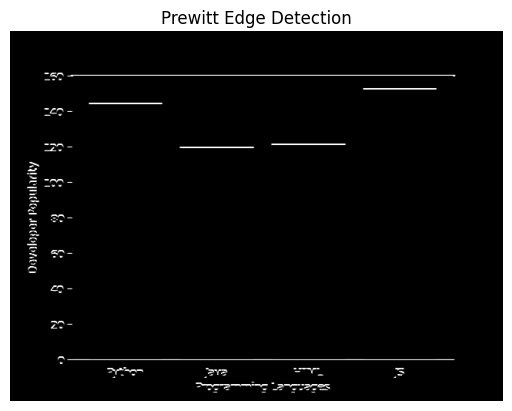

In [186]:
img_prewittx2 = cv2.filter2D(gray, -1, kernelx)
img_prewitty2 = cv2.filter2D(gray, -1, kernely)

img_prewitt2 = img_prewittx2 + img_prewitty2

plt.imshow(img_prewittx2, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

In [187]:
edge_coordinates = np.column_stack(np.where(img_prewitt2 > 0))

print(edge_coordinates)

[[ 54  44]
 [ 54  45]
 [ 54  46]
 ...
 [470 396]
 [470 397]
 [470 398]]


In [188]:
len(edge_coordinates)

11704

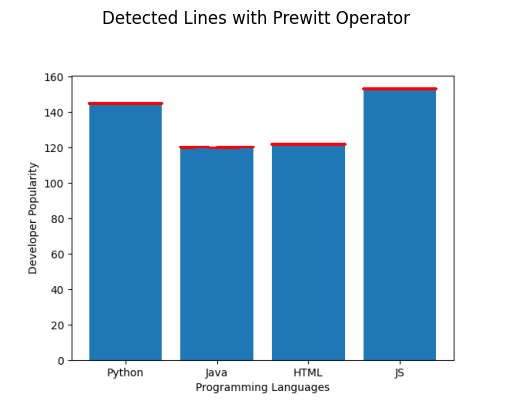

In [189]:
prewittlines2 = image.copy()

linesP = cv2.HoughLinesP(img_prewittx2, 1, np.pi/180, 20, minLineLength=5, maxLineGap=5)

horizontal_lines = []

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        angle = np.arctan2(y2 - y1, x2 - x1) * 180.0 / np.pi
        
        if (x1 > yAxisCord and x2 > yAxisCord) and (y1 < xAxisCord and y2 < xAxisCord):
            # if abs(angle) < 10 or abs(angle) > 170:
                cv2.line(prewittlines2, (x1, y1), (x2, y2), (0, 0, 255), 2)
                horizontal_lines.append([x1, y1, x2, y2]) 
                
prewittlines2 = cv2.cvtColor(prewittlines2, cv2.COLOR_BGR2RGB)
plt.imshow(prewittlines2)
plt.title('Detected Lines with Prewitt Operator')
plt.axis('off')
plt.show()

In [190]:
def merge_close_lines(lines, delta):
    if not lines:
        return []

    lines_sorted = sorted(lines, key=lambda line: line[0])
    
    merged_lines = []
    temp_line_group = [lines_sorted[0]]

    for current_line in lines_sorted[1:]:
        last_line_in_group = temp_line_group[-1]
        if abs(current_line[0] - last_line_in_group[0]) <= delta or abs(current_line[2] - last_line_in_group[2]) <= delta:
            temp_line_group.append(current_line)
        else:
            avg_line = np.mean(temp_line_group, axis=0).astype(int)
            merged_lines.append(avg_line)
            temp_line_group = [current_line]

    if temp_line_group:
        avg_line = np.mean(temp_line_group, axis=0).astype(int)
        merged_lines.append(avg_line)

    return merged_lines

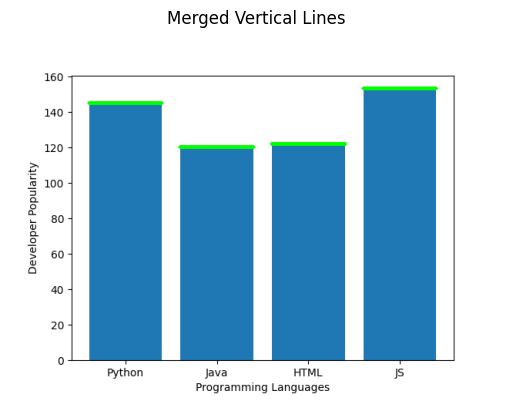

In [191]:
prewittlines3 = image.copy()

merged_lines = merge_close_lines(horizontal_lines, 2)
l=0
for line in merged_lines:
    l+=1
    x1, y1, x2, y2 = line
    cv2.line(prewittlines3, (x1, y1), (x2, y2), (0, 255, 0), 3)

prewittlines3 = cv2.cvtColor(prewittlines3, cv2.COLOR_BGR2RGB)
plt.imshow(prewittlines3)
plt.title('Merged Vertical Lines')
plt.axis('off')
plt.show()

In [192]:
len(merged_lines)

5

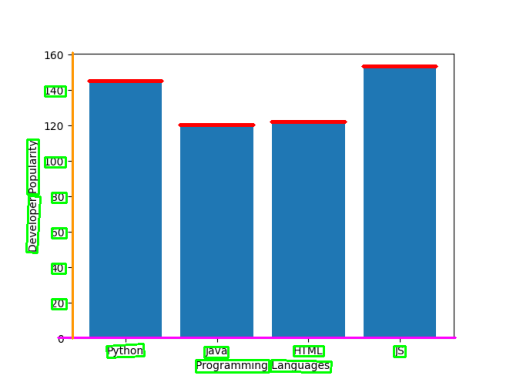

In [193]:
for line in merged_lines:
    x1, y1, x2, y2 = line
    cv2.line(image1223, (x1, y1), (x2, y2), (255, 0, 0), 3)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

In [194]:
def find_nearest_cluster(pixel_color, clusters):
    differences = clusters - pixel_color
    euclidean_distances = np.sqrt(np.sum(differences ** 2, axis=1))
    nearest_cluster_index = np.argmin(euclidean_distances)
    
    return nearest_cluster_index

In [195]:
image_float = image1.astype(np.float32)

topOfBar = []

for line in merged_lines:
    x1, y1, x2, y2 = line
    
    mid_x = (x1 + x2) // 2
    mid_y = (y1+y2) // 2
    
    pixel_above = image_float[max(mid_y - 1, 0), mid_x] 
    pixel_below = image_float[min(mid_y + 1, image1.shape[0] - 1), mid_x]

    cluster_above = find_nearest_cluster(pixel_above, np.array(sorted_colors))
    cluster_below = find_nearest_cluster(pixel_below, np.array(sorted_colors))
    
    if cluster_above == 0 and cluster_below == 1:
        topOfBar.append([x1, y1, x2, y2])

In [196]:
# barValues = []

# for line in topOfBar:
#     x1, y1, x2, y2 = line
    
#     yMid = (y1+y2)/2
    
#     finalVal = abs(yMid - xAxisCord)*vpp
#     barValues.append(finalVal)
    
# barValues

In [197]:
# mapped_values = []

# for indx in range(len(barValues)):
#     mapped_values.append({xtitle: x_labels[indx], ytitle: barValues[indx]})
            

# # Convert the list of dictionaries to a DataFrame
# final = pd.DataFrame(mapped_values)
# final

In [198]:
# final['actuals'] = values
# final

NEW SOL

01

In [199]:
# label_values = {label: None for label, _ in x_labelsWithCent}
# label_values

In [200]:
# for line in topOfBar:
#     x1, y1, x2, y2 = line
#     yMid = (y1+y2)/2
#     xMid = (x1+x2)/2
    
#     finalVal = abs(yMid - fromCal) * vpp + toAdd
    
#     closest_label = min(x_labelsWithCent, key=lambda x: abs(x[1] - xMid))[0]
    
#     label_values[closest_label] = finalVal
    
# label_values

02

In [201]:
# sorted_labels = sorted(x_labelsWithCent, key=lambda x: x[1])
# sorted_x_coords = [x[1] for x in sorted_labels]

In [202]:
# label_values = {label: None for label, _ in sorted_labels}
# label_values

In [203]:
# import bisect

# def find_closest_label(x1):
#     # Find the position where x1 would fit in the sorted list
#     pos = bisect.bisect_left(sorted_x_coords, x1)
    
#     # Check neighbors to find the closest actual label
#     if pos == 0:
#         return sorted_labels[0][0]
#     if pos == len(sorted_labels):
#         return sorted_labels[-1][0]
    
#     # Compare distances to the previous and the next label, if possible
#     before = sorted_labels[pos - 1]
#     after = sorted_labels[pos]
    
#     if abs(before[1] - x1) <= abs(after[1] - x1):
#         return before[0]
#     else:
#         return after[0]

In [204]:
def map_labels_to_points(labels, points):
    # Dictionary to store the result: label text -> y-coordinate from points
    label_to_y_coord = {}
    
    # Iterate through each label
    for label, x_label in labels:
        # Initialize a variable to find the nearest point
        nearest_point = None
        min_distance = float('inf')  # Start with infinity as the minimum distance
        
        # Compare the x-coordinate of the label with each point's x-coordinate
        for x_point, y_point in points:
            # Calculate the distance along the x-axis
            distance = abs(x_label - x_point)
            
            # Update nearest point if this point is closer
            if distance < min_distance:
                min_distance = distance
                nearest_point = y_point
        
        # Map the label text to the y-coordinate of the nearest point
        label_to_y_coord[label] = nearest_point
    
    return label_to_y_coord

In [205]:
mids = []

for line in topOfBar:
    x1, y1, x2, y2 = line
    yMid = (y1+y2)/2
    xMid = (x1+x2)/2
    
    mids.append([xMid, yMid])

mids

[[149.5, 93.0], [248.5, 150.0], [292.0, 150.0], [387.0, 146.0], [505.5, 74.0]]

In [206]:
label_y_mapping = map_labels_to_points(x_labelsWithCent, mids)
label_y_mapping

{'python': 93.0, 'java': 150.0, 'html': 146.0, 'js': 74.0}

In [207]:
for line in label_y_mapping:
    finalVal = abs(label_y_mapping[line] - fromCal) * vpp + toAdd    
    label_y_mapping[line] = finalVal
    
label_y_mapping

{'python': 144.78260869565216,
 'java': 120.0,
 'html': 121.73913043478261,
 'js': 153.04347826086956}

In [208]:
final = pd.DataFrame(list(label_y_mapping.items()), columns=[xtitle, ytitle])
final

,programming languages,developer popularity
0,python,144.782609
1,java,120.000000
2,html,121.739130
3,js,153.043478


In [209]:
data = pd.read_csv('c:\\College\\Sem 08\\Major Project\\Graphs\\Bar\\Testing_New\\testData.csv')

In [210]:
column_data = data[str(ImageNumber)].dropna()
final['actuals'] = column_data
final

,programming languages,developer popularity,actuals
0,python,144.782609,145.0
1,java,120.000000,120.0
2,html,121.739130,122.0
3,js,153.043478,153.0


In [211]:
import sklearn.metrics
import math

mse = sklearn.metrics.mean_squared_error(final['actuals'], final[ytitle])
rmse = math.sqrt(mse)
rmse

0.17117408421765276

In [212]:
final['Error'] = None
final.at[0, 'Error'] = rmse

In [213]:
final.to_csv('c:\\College\\Sem 08\\Major Project\\Graphs\\Bar\\Testing_New\\testImages\\' + f'{str(ImageNumber)}\\{str(ImageNumber)}.csv', index=False, sep=',', encoding='utf-8')

In [214]:
positions = np.arange(len(final['bars']))
width = 0.35

KeyError: 'bars'

NameError: name 'positions' is not defined

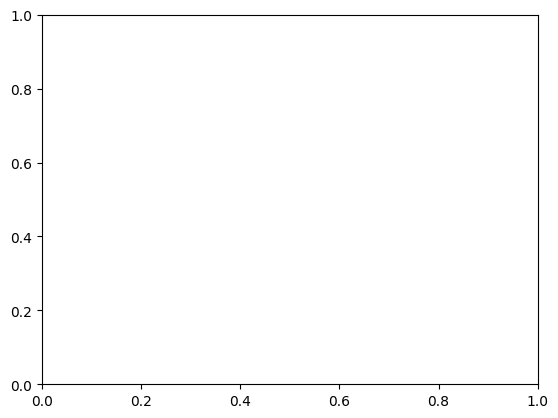

In [119]:
fig, ax = plt.subplots()
bars1 = ax.bar(positions - width/2, final['values'], width, label='Original')
bars2 = ax.bar(positions + width/2, final['actuals'], width, label='Extracted')

ax.set_xlabel('Bars')
ax.set_ylabel('Values')
ax.set_xticks(positions)
ax.set_xticklabels(final['bars'])
ax.legend()

plt.show()